In [11]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib as mpl
import seaborn as sb

# General utils
from tqdm import tqdm
from os import path

from measurements import get_prev_or_next_frame, get_mesh_from_bm_image
# from sklearn import preprocessing, model_selection, feature_selection, metrics, inspection, pipeline
from skimage import io
import pyvista as pv

import ipyvolume as ipv

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
dataset_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles'
all_df = pd.read_pickle(path.join(dataset_dir,f'all_df.pkl'))
basals = pd.read_pickle(path.join(dataset_dir,f'basals.pkl'))
divisions = pd.read_pickle(path.join(dataset_dir,f'divisions.pkl'))
births = pd.read_pickle(path.join(dataset_dir,f'births.pkl'))

df = all_df.droplevel(axis=1,level=1)
df['sqrt(Apical area) / Cell height'] = np.sqrt(df['Apical area']) / df['Cell height']
df['sqrt(Basal area) / Cell height'] = np.sqrt(df['Basal area']) / df['Cell height']
df['Middle-lateral ratio'] = np.sqrt(df['Middle area']) / df['Cell height']
df['Apical-basal ratio'] = np.sqrt(df['Apical area']) / np.sqrt(df['Basal area'])


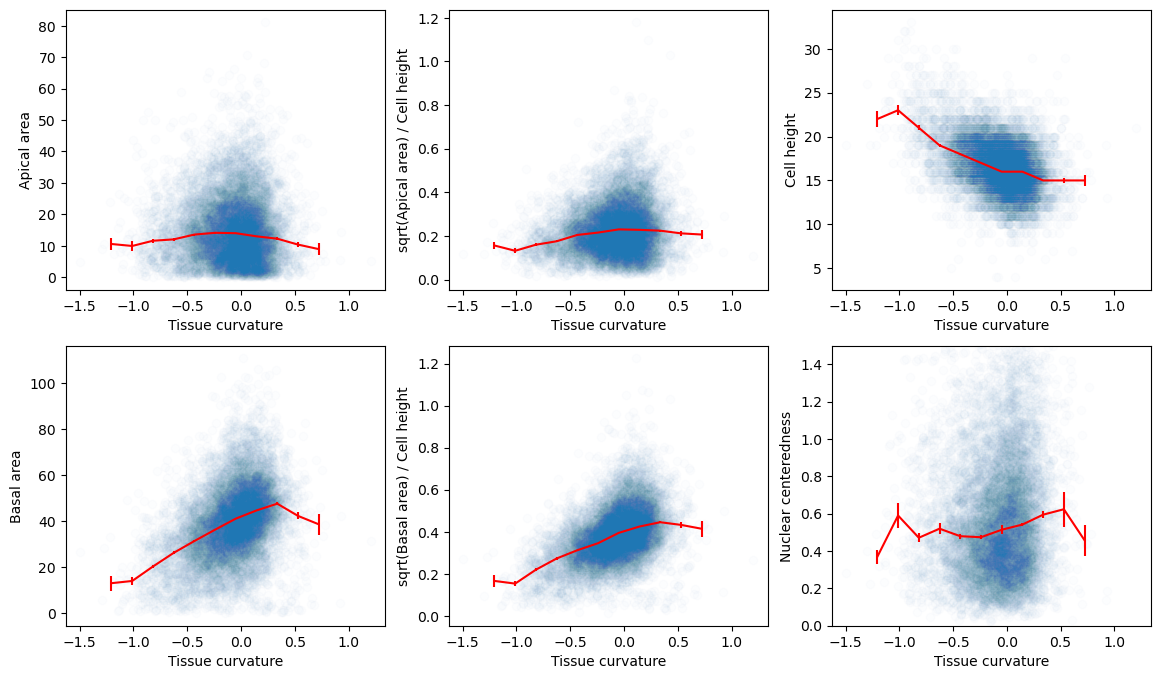

In [72]:
from basicUtils import plot_bin_means

x = 'Mean curvature 5um'

Ys = ['Apical area',
      'sqrt(Apical area) / Cell height',
      'Cell height',
      'Basal area',
      'sqrt(Basal area) / Cell height',
      'Nuclear centeredness']

fig = plt.figure(figsize=[14,8])

for i,y in enumerate(Ys):
    plt.subplot(2,3,i+1)
    plt.scatter(df[x],df[y], alpha=0.01)
    plot_bin_means(df[x],df[y], bin_edges = 15, color='r')
    plt.xlabel('Tissue curvature')
    plt.ylabel(y)
    
plt.subplot(2,3,6)
plt.ylim([0,1.5])

fig.savefig('/Users/xies/Desktop/curvature_morphometrics.svg')

Text(0, 0.5, 'sqrt(Apical area) / Cell length')

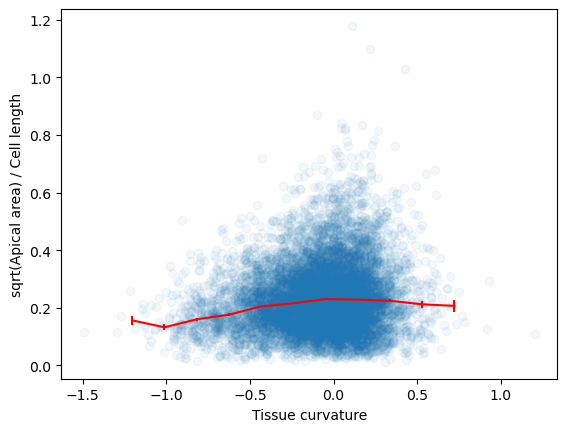

In [31]:
# Apical v. lateral length
from basicUtils import plot_bin_means

apical_to_length = np.sqrt(all_df.droplevel(axis=1,level=1)['Apical area']) / all_df.droplevel(axis=1,level=1)['Cell height']
plt.scatter(all_df.droplevel(axis=1,level=1)['Mean curvature 5um'],apical_to_length, alpha=0.05)
plot_bin_means(all_df.droplevel(axis=1,level=1)['Mean curvature 5um'],apical_to_length, bin_edges = 15, color='r')
plt.xlabel('Tissue curvature')
plt.ylabel('sqrt(Apical area) / Cell length')

Text(0, 0.5, 'sqrt(Basal area) / Cell length')

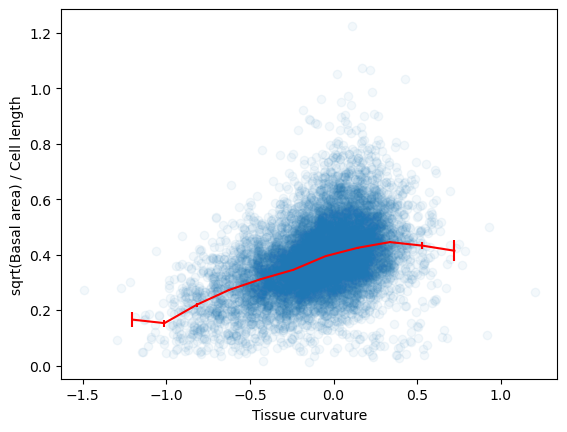

In [33]:
# Basal v. lateral length
basal_to_length = np.sqrt(all_df.droplevel(axis=1,level=1)['Basal area']) / all_df.droplevel(axis=1,level=1)['Cell height']
plt.scatter(all_df.droplevel(axis=1,level=1)['Mean curvature 5um'],basal_to_length, alpha=0.05)

plot_bin_means(all_df.droplevel(axis=1,level=1)['Mean curvature 5um'],basal_to_length, bin_edges = 15, color='r')
plt.xlabel('Tissue curvature')
plt.ylabel('sqrt(Basal area) / Cell length')

(0.0, 2.0)

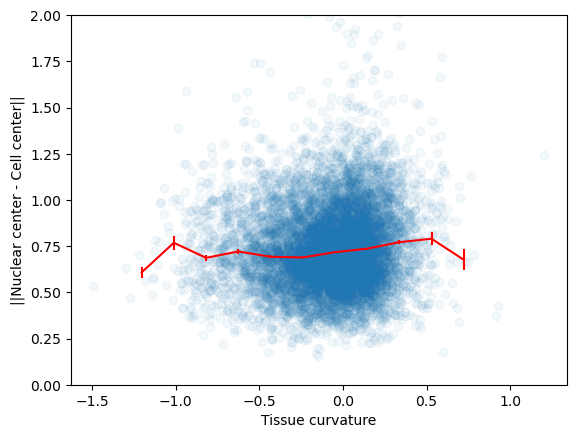

In [38]:
# Nuclear position

nuc_center = np.sqrt(all_df.droplevel(axis=1,level=1)['Nuclear centeredness'])
plt.scatter(all_df.droplevel(axis=1,level=1)['Mean curvature 5um'],nuc_center, alpha=0.05)

plot_bin_means(all_df.droplevel(axis=1,level=1)['Mean curvature 5um'],nuc_center, bin_edges = 15, color='r')
plt.xlabel('Tissue curvature')
plt.ylabel('||Nuclear center - Cell center||')
plt.ylim([0,2])

Text(0, 0.5, 'Cell height')

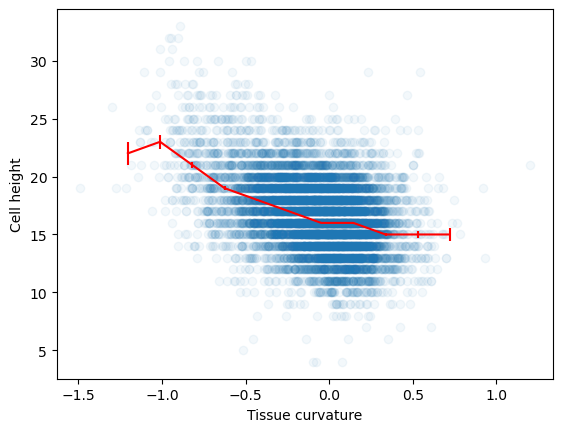

In [37]:
# Cell height

cell_height = all_df.droplevel(axis=1,level=1)['Cell height']
plt.scatter(all_df.droplevel(axis=1,level=1)['Mean curvature 5um'],cell_height, alpha=0.05)

plot_bin_means(all_df.droplevel(axis=1,level=1)['Mean curvature 5um'],cell_height, bin_edges = 15, color='r')
plt.xlabel('Tissue curvature')
plt.ylabel('Cell height')

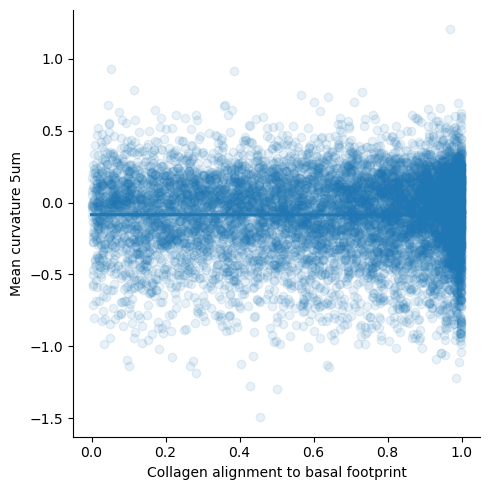

In [74]:
sb.lmplot(df,
          x='Collagen alignment to basal footprint',y='Mean curvature 5um',
         scatter_kws={'alpha':0.1})


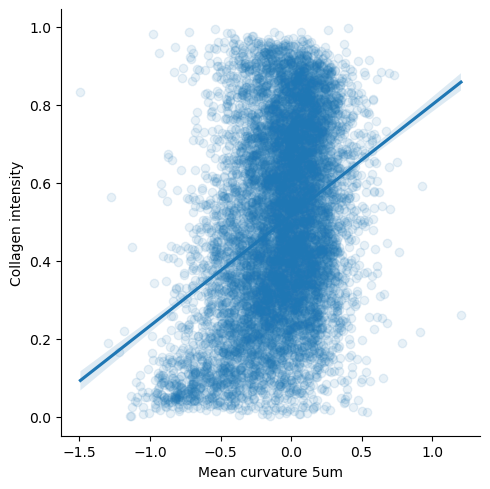

In [78]:
sb.lmplot(df,
          y='Collagen intensity',x='Mean curvature 5um',
         scatter_kws={'alpha':0.1})


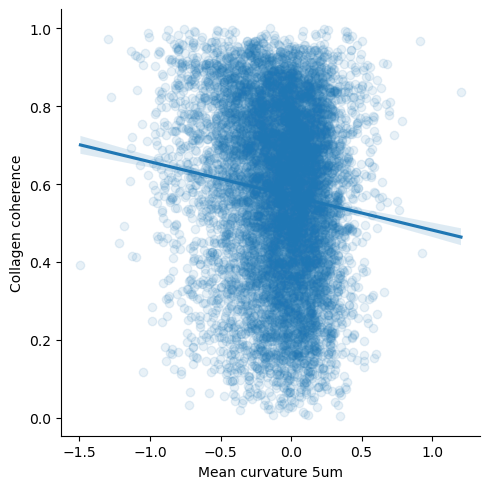

In [77]:
sb.lmplot(df,
          y='Collagen coherence',x='Mean curvature 5um',
         scatter_kws={'alpha':0.1})
